# Model Creation and Training

In [1]:
# importing the libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imgaug import augmenters as iaa
import keras 
from keras import layers
from keras.models import Model
import random

In [2]:
!pip freeze > requirements.txt

### Load Dataset

(6000, 96, 96) (6000, 4)


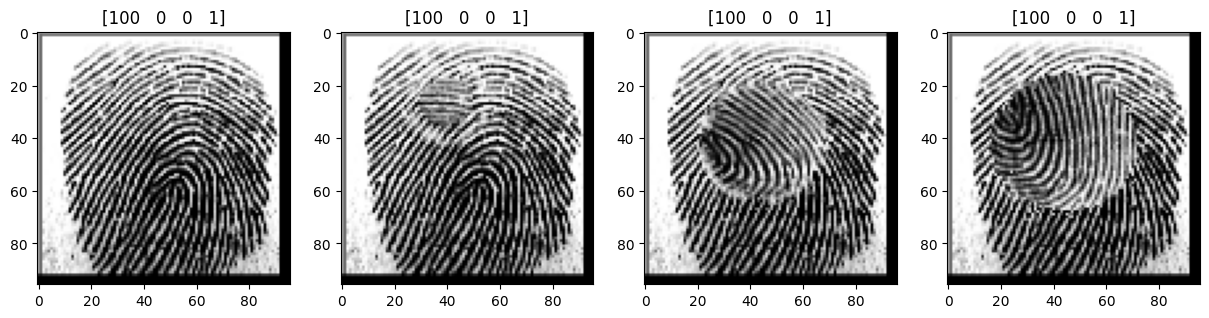

In [2]:
# loading the dataset

x_real = np.load('datasets/x_real.npy')
y_real = np.load('datasets/y_real.npy')
x_easy = np.load('datasets/x_easy.npy')
y_easy = np.load('datasets/y_easy.npy')
x_medium = np.load('datasets/x_medium.npy')
y_medium = np.load('datasets/y_medium.npy')
x_hard = np.load('datasets/x_hard.npy')
y_hard = np.load('datasets/y_hard.npy')

print(x_real.shape, y_real.shape)

plt.figure(figsize=(15, 10))
plt.subplot(1, 4, 1)
plt.title(y_real[0])
plt.imshow(x_real[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 2)
plt.title(y_easy[0])
plt.imshow(x_easy[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 3)
plt.title(y_medium[0])
plt.imshow(x_medium[0].squeeze(), cmap='gray')
plt.subplot(1, 4, 4)
plt.title(y_hard[0])
plt.imshow(x_hard[0].squeeze(), cmap='gray')

### Train Test Split


In [3]:
x_data = np.concatenate([x_easy, x_medium, x_hard], axis=0)
label_data = np.concatenate([y_easy, y_medium, y_hard], axis=0)

print(len(x_data))
print(len(label_data))

x_train, x_val, label_train, label_val = train_test_split(x_data, label_data, test_size= 0.1)

print(x_data.shape, label_data.shape)
print(x_train.shape, label_train.shape)
print(x_val.shape, label_val.shape)

42814
42814
(42814, 96, 96) (42814, 4)
(38532, 96, 96) (38532, 4)
(4282, 96, 96) (4282, 4)


### Preview augmentation

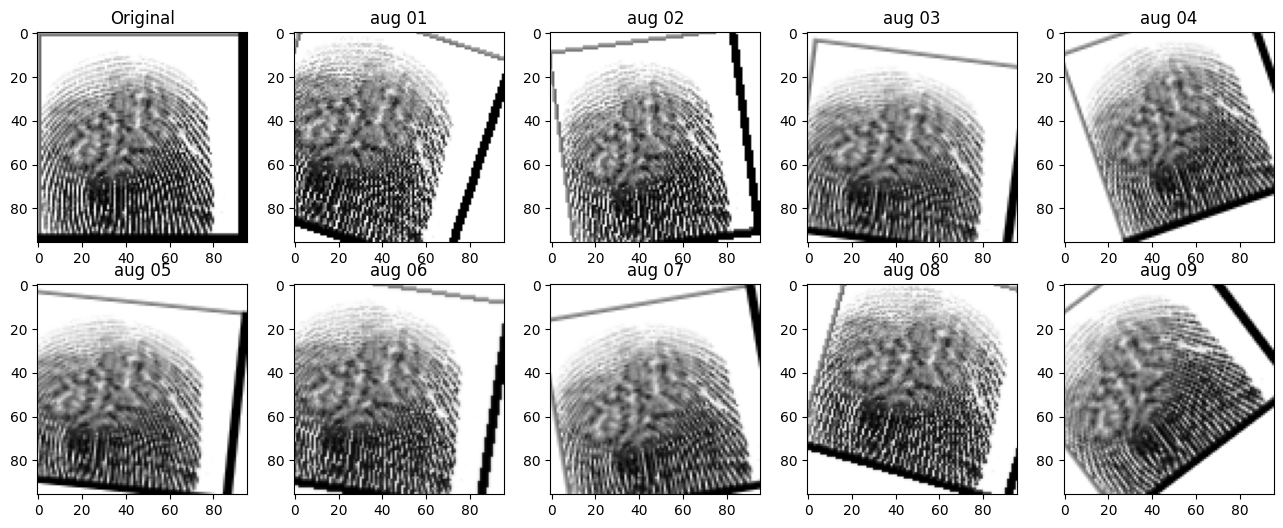

In [4]:
augs = [x_data[40000]]*9

seq = iaa.Sequential([
    #Blur images with a sigma of 0 to 0.5
    iaa.GaussianBlur(sigma=(0, 0.5)),
    iaa.Affine(
        #scale images to 90-110% of their size, individually per axis
        scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
        #translate by -10 to +10% of their height/width (per axis)
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        #rotate by -45 to +45 degrees
        rotate=(-45, 45),
        #use nearest neighbour or  bilinear interpolation (fast)
        order=[0,1],
        #if mode is constant, use a cval between 0 and 255
        cval=255
    )
], random_order=True)

augs = seq.augment_images(augs)

plt.figure(figsize=(16,6))
plt.subplot(2,5,1)
plt.title('Original')
plt.imshow(x_data[40000].squeeze(), cmap='gray')
for i, aug in enumerate(augs):
    plt.subplot(2,5,i+2)
    plt.title('aug %02d' % int(i+1))
    plt.imshow(aug.squeeze(), cmap='gray')

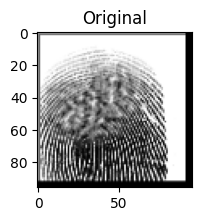

In [5]:
img = x_data[40000]
plt.figure(figsize=(2,5))
plt.title('Original')
plt.imshow(img.squeeze(), cmap='gray')

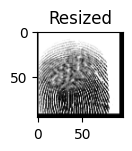

In [6]:
reshaped_img = img.reshape(96, 96, 1)
plt.subplot(2,5,1)
plt.title('Resized')
plt.imshow(reshaped_img.squeeze(), cmap='gray')

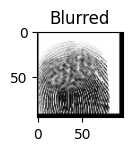

In [7]:
blurred_img = iaa.GaussianBlur(sigma=(0, 0.5)).augment_image(reshaped_img)
plt.subplot(2,5,1)
plt.title('Blurred')
plt.imshow(blurred_img.squeeze(), cmap='gray')
plt.show()

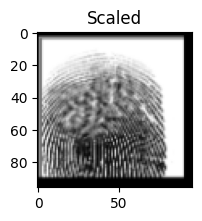

In [8]:
scaled_img = iaa.Affine(scale={"x": (0.9, 1.1), "y": (0.9, 1.1)}).augment_image(blurred_img)
plt.figure(figsize=(2,5))
plt.title('Scaled')
plt.imshow(scaled_img.squeeze(), cmap='gray')
plt.show()

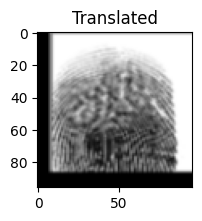

In [9]:
translated_img = iaa.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)}).augment_image(scaled_img)
plt.figure(figsize=(2,5))
plt.title('Translated')
plt.imshow(translated_img.squeeze(), cmap='gray')
plt.show()

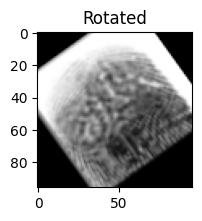

In [10]:
rotated_img = iaa.Affine(rotate=(-45, 45)).augment_image(translated_img)
plt.figure(figsize=(2,5))
plt.title('Rotated')
plt.imshow(rotated_img.squeeze(), cmap='gray')
plt.show()

### Make Label Dictionary Lookup table

In [11]:
Label_real_dict = {}

for i, y in enumerate(y_real):
    key = y.astype(str)
    key = ''.join(key).zfill(6)
    
    Label_real_dict[key] = i

In [12]:
class DataGenerator(keras.utils.Sequence):
    def __init__(self, x,  label,X_real, Label_real_dict, batch_size= 32, shuffle=True):
        "Initialization"
        self.x = x
        self.label = label
        self.x_real = x_real
        self.Label_real_dict = Label_real_dict
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.on_epoch_end()
        
    def __len__(self):
        "denotes the number of batches per epoch"
        return int(np.floor(len(self.x)/self.batch_size))
    
    def __getitem__(self, index):
        "Generates one batch of data"
        # Generate indexes of the batch
        x1_batch = self.x[index*self.batch_size:(index+1)*self.batch_size]
        label_batch = self.label[index*self.batch_size:(index+1)*self.batch_size]
        
        x2_batch = np.empty((self.batch_size, 96, 96), dtype = np.float32)
        y_batch = np.empty((self.batch_size), dtype = np.float32)
        
        #augmentation
        if self.shuffle:
            seq = iaa.Sequential([
                iaa.GaussianBlur(sigma=(0, 0.5)),
                iaa.Affine(
                    scale={"x": (0.8, 1.2), "y": (0.9, 1.1)},
                    translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
                    rotate=(-45, 45),
                    order = [0,1],
                    cval = 255
                ),
                iaa.Add((-10, 10)),
                iaa.Multiply((0.5, 1.5)),
                iaa.Fliplr(0.5),
                iaa.Flipud(0.5)
            ], random_order= True)
            
            x1_batch = seq.augment_images(x1_batch)
            
    # pick matched images(label 1.0) and unmatched images(label 0.0) and put together in batch
    # matched images must be all same, [subject_id(3), gender(1), left_right(1), finger(1)], e.g) 034010
        for i, l in enumerate(label_batch):
            match_key = l.astype(str)
            match_key = ''.join(match_key).zfill(6)
            
            if random.random() > 0.5:
                # put matched image
                x2_batch[i] = self.x_real[self.Label_real_dict[match_key]]
                y_batch[i] = 1.
                
            else:
                # put unmatched image
                while True:
                    unmatch_key, unmatch_index = random.choice(list(self.Label_real_dict.items()))
                    
                    if unmatch_key != match_key:
                        break
                
                x2_batch[i] = self.x_real[unmatch_index]
                y_batch[i] = 0.
    
        return [x1_batch.astype(np.float32)/255., x2_batch.astype(np.float32)/255.], y_batch
    
    def on_epoch_end(self):
        if self.shuffle == True:
            self.x, self.label = shuffle(self.x, self.label)

In [13]:
train_gen = DataGenerator(x_train, label_train,x_real, Label_real_dict, shuffle=True)
val_gen = DataGenerator(x_val, label_val, x_real, Label_real_dict, shuffle=False)

### Creating Model 1

In [14]:
x1 = layers.Input(shape=(96,96,1))
x2 = layers.Input(shape=(96,96,1))

#share weights across both inputs
inputs = layers.Input(shape=(96,96,1))

feature = layers.Conv2D(32, kernel_size= 3, padding= 'same', activation= 'relu')(inputs)
feature = layers.MaxPooling2D(pool_size=2)(feature)

feature = layers.Conv2D(32, kernel_size= 3, padding= 'same', activation= 'relu')(feature)
feature = layers.MaxPooling2D(pool_size=2)(feature)

feature_model = Model(inputs= inputs, outputs= feature)

# Two feature models that share weights
x1_net = feature_model(x1)
x2_net = feature_model(x2)

#Subtract features
net = layers.Subtract()([x1_net, x2_net])

net = layers.Conv2D(32, kernel_size= 3, padding= 'same', activation= 'relu')(net)
net = layers.MaxPooling2D(pool_size=2)(net)

net = layers.Flatten()(net)

net = layers.Dense(64, activation='relu')(net)

net = layers.Dense(1, activation= 'sigmoid')(net)

model = Model(inputs=[x1, x2], outputs=net)

model.compile(loss = 'binary_crossentropy', optimizer= 'adam', metrics=['acc'])

model.summary()




Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 model (Functional)          (None, 24, 24, 32)           9568      ['input_1[0][0]',             
                                                                     'input_2[0][0]']             
                                                                                                  
 subtract (Subtract)         (None, 24, 24, 32)           0         ['model[0][0]',      

### Training the model 1

In [ ]:
history_M1 = model.fit_generator(train_gen, epochs = 15, validation_data=val_gen)

C:\Users\omgha\AppData\Local\Temp\ipykernel_2112\2400440274.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history_M1 = model.fit_generator(train_gen, epochs = 15, validation_data=val_gen)


Epoch 1/15


1204/1204 [==============================] - 229s 186ms/step - loss: 0.5582 - acc: 0.6838 - val_loss: 0.7058 - val_acc: 0.5679
Epoch 2/15
1204/1204 [==============================] - 212s 176ms/step - loss: 0.4117 - acc: 0.8089 - val_loss: 0.4266 - val_acc: 0.7831
Epoch 3/15
1204/1204 [==============================] - 211s 175ms/step - loss: 0.3486 - acc: 0.8480 - val_loss: 0.3907 - val_acc: 0.8210
Epoch 4/15
1204/1204 [==============================] - 211s 175ms/step - loss: 0.3010 - acc: 0.8715 - val_loss: 0.2665 - val_acc: 0.9077
Epoch 5/15
1204/1204 [==============================] - 215s 178ms/step - loss: 0.2845 - acc: 0.8806 - val_loss: 0.2488 - val_acc: 0.9060
Epoch 6/15
1204/1204 [==============================] - 215s 179ms/step - loss: 0.2608 - acc: 0.8930 - val_loss: 0.2131 - val_acc: 0.9297
Epoch 7/15
1204/1204 [==============================] - 216s 179ms/step - loss: 0.2444 - acc: 0.9013 - val_loss: 0.1545 - val_acc: 0.9549
Epoch 8/15
1204/1204 [==========

### Evaluation

In [17]:
model = keras.saving.load_model('FpM_Model_sub.h5')  

1/1 [==============================] - 0s 58ms/step


C:\Users\omgha\AppData\Local\Temp\ipykernel_23468\949556971.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title('O: %.02f, %s' % (pred_rx, ry))
C:\Users\omgha\AppData\Local\Temp\ipykernel_23468\949556971.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title('X: %.02f, %s' % (pred_ux, uy))


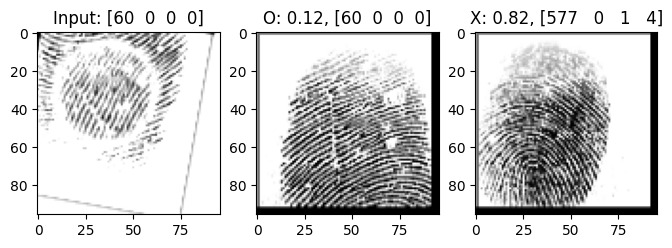

In [18]:

random_idx = random.randint(0, len(x_val))

random_img = x_val[random_idx]
random_label = label_val[random_idx]

seq = iaa.Sequential([
    iaa.GaussianBlur(sigma=(0, 0.5)),
    iaa.Affine(
        scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        rotate=(-30, 30),
        order=[0, 1],
        cval=255
    ),
    iaa.Add((-10, 10)),
    iaa.Multiply((0.5, 1.5)),
    iaa.Fliplr(0.5),
    iaa.Flipud(0.5)
], random_order=True)

random_img = seq.augment_image(random_img).reshape((1, 96, 96, 1)).astype(np.float32) / 255.

# matched image
match_key = random_label.astype(str)
match_key = ''.join(match_key).zfill(6)

rx = x_real[Label_real_dict[match_key]].reshape((1, 96, 96)).astype(np.float32) / 255.
ry = y_real[Label_real_dict[match_key]]

pred_rx = model.predict([random_img, rx])


# unmatched image
unmatch_key, unmatch_idx = random.choice(list(Label_real_dict.items()))

ux = x_real[unmatch_idx].reshape((1, 96, 96)).astype(np.float32) / 255.
uy = y_real[unmatch_idx]

pred_ux = model.predict([random_img, ux])

plt.figure(figsize=(8, 4))
plt.subplot(1, 3, 1)
plt.title('Input: %s' %random_label)
plt.imshow(random_img.squeeze(), cmap='gray')
plt.subplot(1, 3, 2)
plt.title('O: %.02f, %s' % (pred_rx, ry))
plt.imshow(rx.squeeze(), cmap='gray')
plt.subplot(1, 3, 3)
plt.title('X: %.02f, %s' % (pred_ux, uy))
plt.imshow(ux.squeeze(), cmap='gray')

In [24]:
model.save('FpM_Model_sub.h5')

In [22]:
import time
i = 0
time_taken = []
loss = []
while i < 100:
    start = time.time()
    
    random_idx = random.randint(0, len(x_val))

    random_img = x_val[random_idx]
    random_label = label_val[random_idx]

    seq = iaa.Sequential([
        iaa.GaussianBlur(sigma=(0, 0.5)),
        iaa.Affine(
            scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
            translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
            rotate=(-30, 30),
            order=[0, 1],
            cval=255
        )
    ], random_order=True)

    random_img = seq.augment_image(random_img).reshape((1, 96, 96, 1)).astype(np.float32) / 255.

    # matched image
    match_key = random_label.astype(str)
    match_key = ''.join(match_key).zfill(6)

    rx = x_real[Label_real_dict[match_key]].reshape((1, 96, 96)).astype(np.float32) / 255.
    ry = y_real[Label_real_dict[match_key]]

    pred_rx = model.predict([random_img, rx])
    
    end = time.time()
    time_taken.append(end - start)
    loss.append(pred_rx)
    i+=1    

1/1 [==============================] - 0s 41ms/step


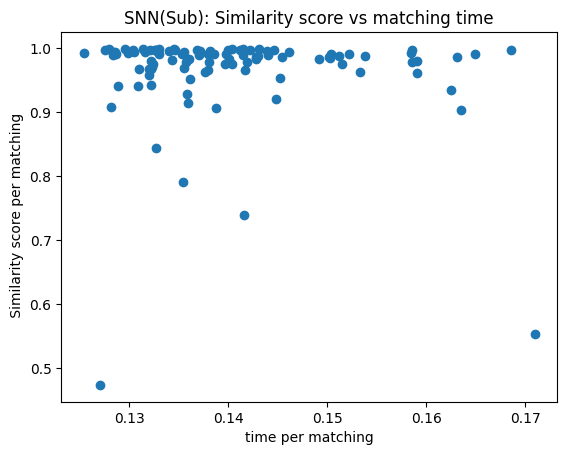

In [23]:
plt.title("SNN(Sub): Similarity score vs matching time")
plt.xlabel("time per matching")
plt.ylabel(" Similarity score per matching")
plt.scatter(time_taken, loss)
plt.show()

In [21]:
mean = np.sum(time_taken)/len(time_taken)
print(mean)

0.14643144130706787


### Creating Model 2

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Input layers for two fingerprint images
x1 = layers.Input(shape=(96, 96, 1))
x2 = layers.Input(shape=(96, 96, 1))

# Shared CNN feature extractor for both inputs
inputs = layers.Input(shape=(96, 96, 1))
feature = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(inputs)
feature = layers.MaxPooling2D(pool_size=2)(feature)

feature = layers.Conv2D(32, kernel_size=3, padding='same', activation='relu')(feature)
feature = layers.MaxPooling2D(pool_size=2)(feature)

# Feature extraction model
feature_model = Model(inputs=inputs, outputs=feature)

# Apply the same CNN to both inputs
x1_net = feature_model(x1)
x2_net = feature_model(x2)

# Flatten the feature maps before computing the distance
x1_net = layers.Flatten()(x1_net)
x2_net = layers.Flatten()(x2_net)

# Calculate the L1 Distance between the two feature vectors
l1_distance = layers.Lambda(lambda tensors: tf.abs(tensors[0] - tensors[1]))([x1_net, x2_net])

# Fully connected layers to predict whether the fingerprints match
net = layers.Dense(64, activation='relu')(l1_distance)
net = layers.Dense(1, activation='sigmoid')(net)

# Define the final model
model_2 = Model(inputs=[x1, x2], outputs=net)

# Compile the model with binary crossentropy and Adam optimizer
model_2.compile(loss = 'binary_crossentropy', optimizer= 'adam', metrics=['acc'])


# Summary of the model
model_2.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 input_5 (InputLayer)        [(None, 96, 96, 1)]          0         []                            
                                                                                                  
 model_2 (Functional)        (None, 24, 24, 32)           9568      ['input_4[0][0]',             
                                                                     'input_5[0][0]']             
                                                                                                  
 flatten_1 (Flatten)         (None, 18432)                0         ['model_2[0][0]']       

### Training the model 2

In [20]:
history_M2 = model_2.fit_generator(train_gen, epochs = 15, validation_data=val_gen)

C:\Users\omgha\AppData\Local\Temp\ipykernel_2112\744114852.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history_M2 = model_2.fit_generator(train_gen, epochs = 15, validation_data=val_gen)


Epoch 1/15
1204/1204 [==============================] - 236s 194ms/step - loss: 0.6212 - acc: 0.6404 - val_loss: 0.6313 - val_acc: 0.5491
Epoch 2/15
1204/1204 [==============================] - 217s 180ms/step - loss: 0.5480 - acc: 0.7133 - val_loss: 0.8874 - val_acc: 0.5388
Epoch 3/15
1204/1204 [==============================] - 196s 162ms/step - loss: 0.5081 - acc: 0.7442 - val_loss: 0.7060 - val_acc: 0.5726
Epoch 4/15
1204/1204 [==============================] - 207s 172ms/step - loss: 0.4752 - acc: 0.7703 - val_loss: 0.8384 - val_acc: 0.5578
Epoch 5/15
1204/1204 [==============================] - 225s 186ms/step - loss: 0.4545 - acc: 0.7824 - val_loss: 1.0476 - val_acc: 0.5482
Epoch 6/15
1204/1204 [==============================] - 218s 181ms/step - loss: 0.4331 - acc: 0.7966 - val_loss: 1.0043 - val_acc: 0.5632
Epoch 7/15
1204/1204 [==============================] - 207s 172ms/step - loss: 0.4221 - acc: 0.8029 - val_loss: 1.1558 - val_acc: 0.5449
Epoch 8/15
1204/1204 [============

In [21]:
import time
i = 0
time_taken_2 = []
accuracy_2 = []
while i < 100:
    start = time.time()
    
    random_idx = random.randint(0, len(x_val))

    random_img = x_val[random_idx]
    random_label = label_val[random_idx]

    seq = iaa.Sequential([
        iaa.GaussianBlur(sigma=(0, 0.5)),
        iaa.Affine(
            scale={"x": (0.9, 1.1), "y": (0.9, 1.1)},
            translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
            rotate=(-30, 30),
            order=[0, 1],
            cval=255
        )
    ], random_order=True)

    random_img = seq.augment_image(random_img).reshape((1, 96, 96, 1)).astype(np.float32) / 255.

    # matched image
    match_key = random_label.astype(str)
    match_key = ''.join(match_key).zfill(6)

    rx = x_real[Label_real_dict[match_key]].reshape((1, 96, 96)).astype(np.float32) / 255.
    ry = y_real[Label_real_dict[match_key]]

    pred_rx = model_2.predict([random_img, rx])
    
    end = time.time()
    time_taken_2.append(end - start)
    accuracy_2.append(pred_rx)
    i+=1    

1/1 [==============================] - 0s 49ms/step


IndexError: index 4282 is out of bounds for axis 0 with size 4282

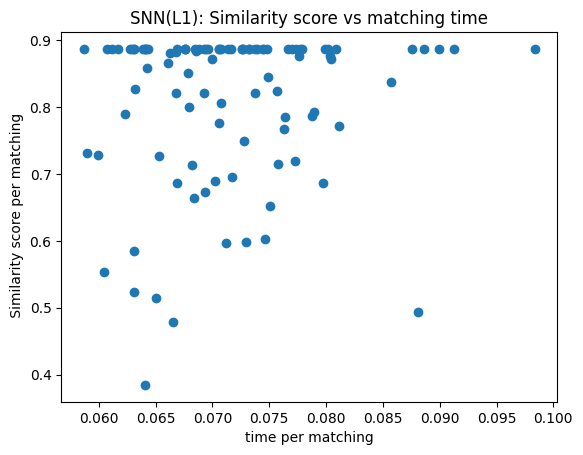

In [ ]:
plt.title("SNN(L1): Similarity score vs matching time")
plt.xlabel("time per matching")
plt.ylabel(" Similarity score per matching")
plt.scatter(time_taken_2, accuracy_2)
plt.show()

In [ ]:
SNN_l1_train_accuracy = history_M2.history['acc']
SNN_l1_validation_accuracy = history_M2.history["val_acc"]
SNN_l1_train_loss = history_M2.history["loss"]
SNN_l1_validation_loss = history_M2.history["val_loss"]

In [ ]:
epochs = range(1, len(SNN_l1_train_accuracy) + 1) 

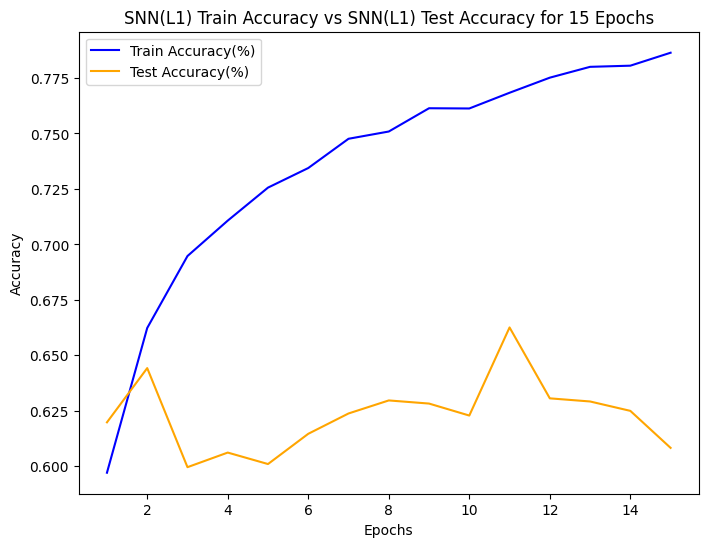

In [ ]:
# Plotting Train vs Test Accuracy
plt.figure(figsize=(8, 6))

# Plot Train Accuracy
plt.plot(epochs, SNN_l1_train_accuracy, label='Train Accuracy(%)', color='blue')

# Plot Test Accuracy
plt.plot(epochs, SNN_l1_validation_accuracy, label='Test Accuracy(%)', color='orange')

# Adding title and labels
plt.title('SNN(L1) Train Accuracy vs SNN(L1) Test Accuracy for 15 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Adding a legend
plt.legend()

# Display the plot
plt.show()


In [ ]:
SNN_sub_train_accuracy = history_M1.history['acc']
SNN_sub_validation_accuracy = history_M1.history['val_acc']
SNN_sub_train_loss = history_M1.history['loss']
SNN_sub_validation_loss = history_M1.history['val_loss']

In [ ]:
epochs = range(1, len(SNN_sub_train_accuracy) + 1) 

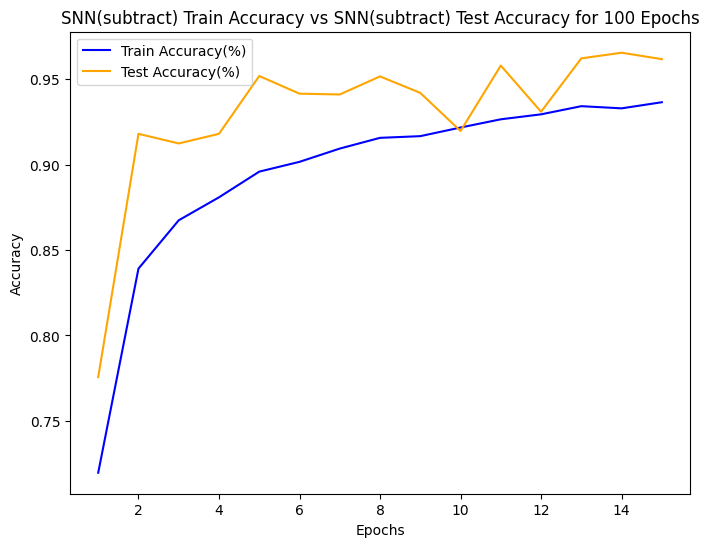

In [ ]:
# Plotting Train vs Test Accuracy
plt.figure(figsize=(8, 6))

# Plot Train Accuracy
plt.plot(epochs, SNN_sub_train_accuracy, label='Train Accuracy(%)', color='blue')

# Plot Test Accuracy
plt.plot(epochs, SNN_sub_validation_accuracy, label='Test Accuracy(%)', color='orange')

# Adding title and labels
plt.title('SNN(subtract) Train Accuracy vs SNN(subtract) Test Accuracy for 100 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Adding a legend
plt.legend()

# Display the plot
plt.show()


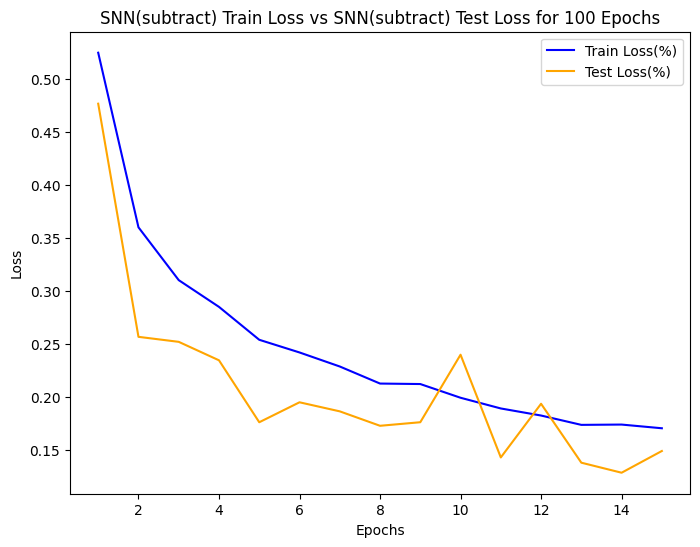

In [ ]:
# Plotting Train vs Test Accuracy
plt.figure(figsize=(8, 6))

# Plot Train Accuracy
plt.plot(epochs, SNN_sub_train_loss, label='Train Loss(%)', color='blue')

# Plot Test Accuracy
plt.plot(epochs, SNN_sub_validation_loss, label='Test Loss(%)', color='orange')

# Adding title and labels
plt.title('SNN(subtract) Train Loss vs SNN(subtract) Test Loss for 100 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# Adding a legend
plt.legend()

# Display the plot
plt.show()


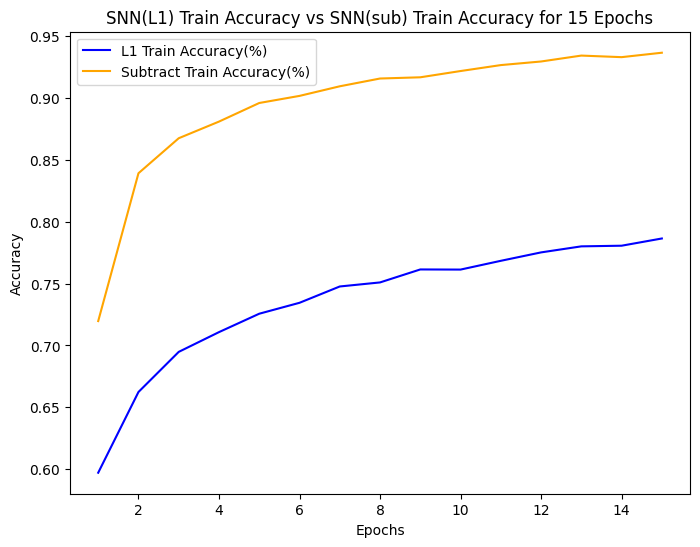

In [ ]:
# Plotting Train vs Test Accuracy
plt.figure(figsize=(8, 6))

# Plot Train Accuracy
plt.plot(epochs, SNN_l1_train_accuracy, label='L1 Train Accuracy(%)', color='blue')

# Plot Test Accuracy
plt.plot(epochs, SNN_sub_train_accuracy, label='Subtract Train Accuracy(%)', color='orange')

# Adding title and labels
plt.title('SNN(L1) Train Accuracy vs SNN(sub) Train Accuracy for 15 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Adding a legend
plt.legend()

# Display the plot
plt.show()


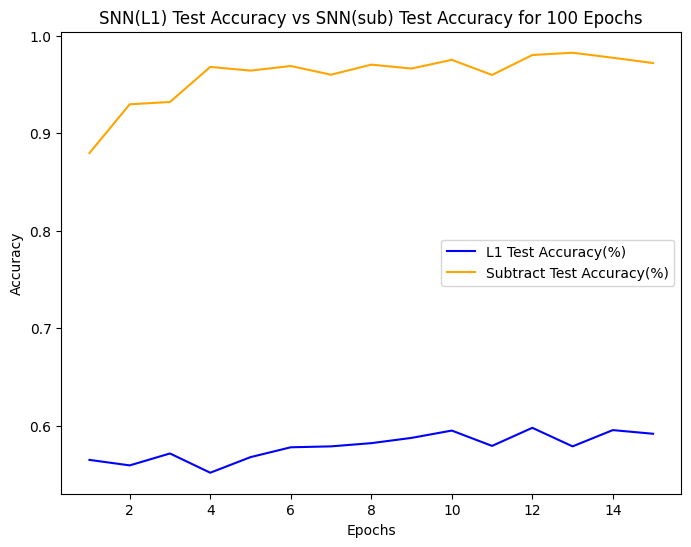

In [ ]:
# Plotting Train vs Test Accuracy
plt.figure(figsize=(8, 6))

# Plot Train Accuracy
plt.plot(epochs, SNN_l1_validation_accuracy, label='L1 Test Accuracy(%)', color='blue')

# Plot Test Accuracy
plt.plot(epochs, SNN_sub_validation_accuracy, label='Subtract Test Accuracy(%)', color='orange')

# Adding title and labels
plt.title('SNN(L1) Test Accuracy vs SNN(sub) Test Accuracy for 100 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Adding a legend
plt.legend()

# Display the plot
plt.show()


In [ ]:
model.save('FpM_Model_sub.tflite')

INFO:tensorflow:Assets written to: FpM_Model_sub.tflite\assets


INFO:tensorflow:Assets written to: FpM_Model_sub.tflite\assets


-------------------------------------------------------------------------------------------------------------------------------------------------------------

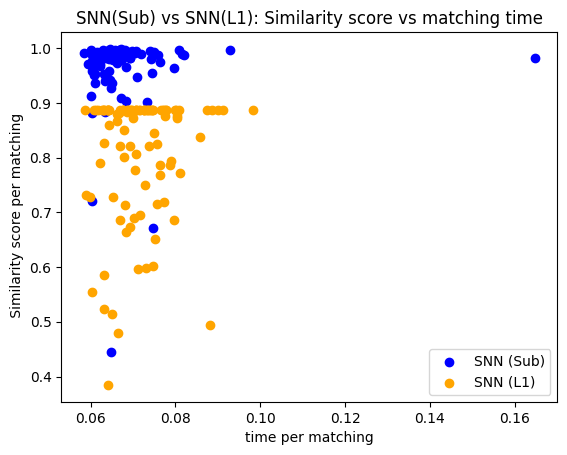

In [ ]:
plt.title("SNN(Sub) vs SNN(L1): Similarity score vs matching time")
plt.xlabel("time per matching")
plt.ylabel(" Similarity score per matching")
plt.scatter(time_taken, loss,label = 'SNN (Sub)', color = 'blue')
plt.scatter(time_taken_2, accuracy_2,label = 'SNN (L1)', color = 'orange')
plt.legend()
plt.show()